In [2]:
# Cella 1: Setup, configurazione e funzioni di utilità

from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber

import logging
logging.getLogger("pdfminer").setLevel(logging.ERROR)

BASE_DATA_DIR = Path("data")

ROUND_DIRS = sorted(
    d for d in BASE_DATA_DIR.iterdir()
    if d.is_dir() and any(d.glob("*.pdf"))
)
CACHE_PATH = Path("data/processed/team_match_history.parquet")
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

MATCHES_PER_ROUND = 10  # 20 squadre di Serie A -> 10 partite a giornata

CORE_METRICS = [
    "Tiri", "Tiri in porta", "Tiri fuori", "Tiri respinti",
    "Passaggi chiave", "Falli fatti", "Corner", "Fuorigioco", "Dribbling",
    "Passaggi riusciti", "Passaggi riusciti/tentati (%)",
    "Passaggi riusciti in ultimo terzo", "Palloni giocati in avanti riusciti",
    "Passaggi lunghi", "Parate", "Recuperi",
]

TEAM_NAME_PATTERN = r"[A-ZÀ-ÖØ-Ý]+(?:\s+[A-ZÀ-ÖØ-Ý]+)*"
MATCH_LINE_PATTERN = re.compile(rf"({TEAM_NAME_PATTERN})\s+(\d+)-(\d+)\s+({TEAM_NAME_PATTERN})")


def parse_number(value: str) -> float:
    """Converte una stringa numerica (virgola decimale o %) in float."""
    return float(value.replace(",", ".").replace("%", "").strip())


def extract_page_texts(report_path: Path, max_pages: int | None = None) -> list[str]:
    """Estrae il testo di ogni pagina. max_pages limita l'estrazione per i pass leggeri."""
    with pdfplumber.open(report_path) as pdf:
        pages = pdf.pages[:max_pages] if max_pages else pdf.pages
        return [page.extract_text() or "" for page in pages]


def extract_match_metadata(pages: list[str]) -> dict[str, object]:
    """Legge giornata, data e risultato dalle prime pagine.
    Il pattern TEAM punteggio-punteggio TEAM viene cercato riga per riga
    con fullmatch: SOLO una riga che coincide per intero può fare match.
    Necessario perché \s+ include il newline — un .search() sull'intero
    blocco di testo di pagina "scivolerebbe" su più righe reali,
    agganciando testo spurio (es. l'anno del campionato) invece della
    riga di risultato vera."""
    match = None
    for text in pages[:3]:
        for line in text.splitlines():
            candidate = MATCH_LINE_PATTERN.fullmatch(line.strip())
            if candidate:
                match = candidate
                break
        if match:
            break
    if match is None:
        raise ValueError("Risultato non riconosciuto nelle prime pagine.")

    home, home_score, away_score, away = match.groups()
    home_score, away_score = int(home_score), int(away_score)
    winner = home if home_score > away_score else away if away_score > home_score else "Pareggio"

    giornata_match = re.search(r"Giornata\s+(\d+)", pages[0])
    date_match = re.search(r"(\d{2}/\d{2}/\d{4})", pages[0])
    giornata = int(giornata_match.group(1)) if giornata_match else None
    match_date = date_match.group(1) if date_match else None

    match_id = (
        f"G{giornata:02d}_{home}_{away}" if giornata is not None
        else f"{home}_{away}_{match_date or 'UNK'}"
    )

    return {
        "match_id": match_id, "giornata": giornata, "match_date": match_date,
        "home": home, "away": away,
        "home_score": home_score, "away_score": away_score, "winner": winner,
    }


def find_page(pages: list[str], marker: str) -> tuple[int, str]:
    for page_number, text in enumerate(pages, start=1):
        if marker in text:
            return page_number, text
    raise ValueError(f"Sezione non trovata: {marker}")


def parse_team_metric_line(section: str, metric: str) -> list[str]:
    pattern = re.compile(rf"(?<!\w){re.escape(metric)}(?!\w)\s+([\d.,%\s/]+)$")
    for line in section.splitlines():
        m = pattern.search(line.strip())
        if m:
            return re.findall(r"\d+(?:[.,]\d+)?", m.group(1))
    return []

NUMERIC_TOKEN = re.compile(r"^\d+(?:[.,]\d+)?%?$")


def extract_stats_page_words(report_path: Path, page_number: int) -> list[dict]:
    """Estrae le words con bounding box (x0, x1, top) della pagina indicata,
    necessarie per la disambiguazione posizionale casa/ospite."""
    with pdfplumber.open(report_path) as pdf:
        return pdf.pages[page_number - 1].extract_words()


def group_words_into_lines(words: list[dict], y_tolerance: float = 2.0) -> list[list[dict]]:
    """Raggruppa le words in righe visive per coordinata Y ('top'), ordinate
    dall'alto in basso. Tolleranza stretta apposta: la stessa pagina che ha
    fuso 'GENOA NAPOLI' e 'Tiri 16 9' in extract_text() potrebbe farlo anche
    qui se il gap verticale reale è piccolo — con tolleranza 2pt separiamo
    correttamente anche righe molto ravvicinate."""
    lines: list[list[dict]] = []
    for word in sorted(words, key=lambda w: (w["top"], w["x0"])):
        for line in lines:
            if abs(line[0]["top"] - word["top"]) <= y_tolerance:
                line.append(word)
                break
        else:
            lines.append([word])
    for line in lines:
        line.sort(key=lambda w: w["x0"])
    return sorted(lines, key=lambda line: line[0]["top"])


def filter_lines_after_marker(lines: list[list[dict]], marker_tokens: list[str]) -> list[list[dict]]:
    """Tiene solo le righe dopo quella che contiene tutti i marker_tokens
    (es. ['STATISTICHE','SQUADRE']), per non far contaminare la calibrazione
    da sezioni sopra come POSSESSO PALLA."""
    for index, line in enumerate(lines):
        texts = [w["text"] for w in line]
        if all(token in texts for token in marker_tokens):
            return lines[index + 1:]
    return lines  # marker non trovato: fallback, meglio di niente


def split_label_and_values(line: list[dict]) -> tuple[str, list[dict]]:
    """Separa una riga in (etichetta, token numerici finali), prendendo i
    numeri dalla coda finché matchano NUMERIC_TOKEN — indipendente da quante
    parole compongono l'etichetta o da testo fuso davanti (es. nomi squadra)."""
    value_tokens: list[dict] = []
    for word in reversed(line):
        if NUMERIC_TOKEN.match(word["text"]):
            value_tokens.insert(0, word)
        else:
            break
    label = " ".join(w["text"] for w in line[: len(line) - len(value_tokens)])
    return label, value_tokens


def label_matches_metric(label: str, metric: str) -> bool:
    """Confronta gli ultimi N token dell'etichetta con quelli della metrica
    (suffix match), non l'uguaglianza esatta — robusto a testo fuso davanti."""
    label_tokens, metric_tokens = label.split(), metric.split()
    return len(label_tokens) >= len(metric_tokens) and label_tokens[-len(metric_tokens):] == metric_tokens


def build_column_reference(lines: list[list[dict]]) -> tuple[float, float] | None:
    """Calibra il CENTRO ORIZZONTALE (x_center) delle colonne casa/ospite usando
    tutte le righe NON ambigue (esattamente 2 valori). Rispetto a x1, il centro
    è molto più stabile sia con cifre singole che doppie."""
    home_centers, away_centers = [], []
    for line in lines:
        _, values = split_label_and_values(line)
        if len(values) == 2:
            home_centers.append((values[0]["x0"] + values[0]["x1"]) / 2.0)
            away_centers.append((values[1]["x0"] + values[1]["x1"]) / 2.0)
    if not home_centers:
        return None
    return float(np.median(home_centers)), float(np.median(away_centers))


def recover_ambiguous_metric(
    lines: list[list[dict]], metric: str, column_ref: tuple[float, float], min_margin: float = 2.0
) -> tuple[float, float] | None:
    """Per la riga di 'metric' con UN SOLO valore, decide casa/ospite confrontando
    il centro orizzontale del valore con le colonne calibrate. Se il margine è
    sotto min_margin (troppo ambiguo), ritorna None lasciando il fallback a fillna."""
    home_ref, away_ref = column_ref
    for line in lines:
        label, values = split_label_and_values(line)
        if len(values) != 1 or not label_matches_metric(label, metric):
            continue
        
        val_center = (values[0]["x0"] + values[0]["x1"]) / 2.0
        value = parse_number(values[0]["text"])
        
        dist_home = abs(val_center - home_ref)
        dist_away = abs(val_center - away_ref)
        
        if abs(dist_home - dist_away) < min_margin:
            return None
        return (value, 0.0) if dist_home < dist_away else (0.0, value)
    return None

In [3]:
# Cella 2: Parsing del report completo

def parse_full_report(report_path: Path) -> dict[str, object]:
    pages = extract_page_texts(report_path)
    parsed = extract_match_metadata(pages)
    parsed["pdf_name"] = report_path.name
    parsed["pages"] = len(pages)

    stats_page, stats_text = find_page(pages, "STATISTICHE SQUADRE")
    section = stats_text[stats_text.index("STATISTICHE SQUADRE"):]
    parsed["stats_page"] = stats_page

    raw_lines = group_words_into_lines(extract_stats_page_words(report_path, stats_page))
    stats_lines = filter_lines_after_marker(raw_lines, ["STATISTICHE", "SQUADRE"])
    column_ref = build_column_reference(stats_lines)

    for metric in CORE_METRICS:
        values = parse_team_metric_line(section, metric)
        if len(values) >= 2:
            parsed[f"{metric}_home"] = parse_number(values[0])
            parsed[f"{metric}_away"] = parse_number(values[-1])
            parsed[f"{metric}_status"] = "parsed"
            continue

        recovered = recover_ambiguous_metric(stats_lines, metric, column_ref) if column_ref else None
        if recovered is not None:
            parsed[f"{metric}_home"], parsed[f"{metric}_away"] = recovered
            parsed[f"{metric}_status"] = "recovered_zero"
        else:
            parsed[f"{metric}_home"] = np.nan
            parsed[f"{metric}_away"] = np.nan
            parsed[f"{metric}_status"] = "review"

    return parsed

In [4]:
# Cella 3: Parsing di tutte le giornate disponibili in data/

records: list[dict] = []
parse_errors: list[dict] = []

for round_dir in ROUND_DIRS:
    pdf_files = sorted(round_dir.glob("*.pdf"))
    for pdf_path in pdf_files:
        try:
            records.append(parse_full_report(pdf_path))
        except Exception as exc:
            parse_errors.append({
                "folder": round_dir.name,
                "file": pdf_path.name,
                "error": str(exc),
            })

match_stats_df = (
    pd.DataFrame(records)
    .sort_values(["giornata", "match_id"])
    .reset_index(drop=True)
)

print(f"Cartelle giornata trovate: {[d.name for d in ROUND_DIRS]}")
print(f"PDF parsati correttamente: {len(match_stats_df)}")
print(f"Giornate coperte: {sorted(match_stats_df['giornata'].dropna().unique())}")

if parse_errors:
    print(f"\n⚠️ {len(parse_errors)} PDF con errori di parsing:")
    display(pd.DataFrame(parse_errors))

display(match_stats_df[["match_id", "giornata", "match_date", "home", "away", "home_score", "away_score", "pdf_name"]])

Cartelle giornata trovate: ['prima', 'quarta', 'quinta', 'seconda', 'terza']
PDF parsati correttamente: 50
Giornate coperte: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,match_id,giornata,match_date,home,away,home_score,away_score,pdf_name
0,G01_ATALANTA_SASSUOLO,1,23/08/2026,ATALANTA,SASSUOLO,2,1,44127a94657a4a11832c118eed9e9421_ATASAS_MatchR...
1,G01_BOLOGNA_LAZIO,1,24/08/2026,BOLOGNA,LAZIO,0,1,e5e1363d12bf4adfb494f64c3654c16c_BOLLAZ_MatchR...
2,G01_FROSINONE_JUVENTUS,1,23/08/2026,FROSINONE,JUVENTUS,0,1,87efe7bc3660456ca4b7c9426ad0fa85_FROJUV_MatchR...
3,G01_GENOA_NAPOLI,1,22/08/2026,GENOA,NAPOLI,0,2,160ddffa5500412baf2c48c2ea255675_GENNAP_MatchR...
4,G01_INTER_MONZA,1,22/08/2026,INTER,MONZA,4,1,1cc7b922e8d44f93a52fb4bf8858e454_INTMON_MatchR...
5,G01_PARMA_CAGLIARI,1,22/08/2026,PARMA,CAGLIARI,0,1,5e0f7484954c4f8c823ff624cc0ab888_PARCAG_MatchR...
6,G01_ROMA_FIORENTINA,1,24/08/2026,ROMA,FIORENTINA,4,0,8555be7ed28343a196cce24873f245e2_ROMFIO_MatchR...
7,G01_TORINO_MILAN,1,23/08/2026,TORINO,MILAN,1,2,48a4a03799a54fcfa786527ed54d723b_TORMIL_MatchR...
8,G01_UDINESE_COMO,1,22/08/2026,UDINESE,COMO,1,1,50b79ed0dfd04af4804eb12f69123766_UDICOM_MatchR...
9,G01_VENEZIA_LECCE,1,23/08/2026,VENEZIA,LECCE,0,2,e4fe3e637d6e496fb6a905a0b183ed1c_VENLEC_MatchR...


In [5]:
# Cella 4: Dataset squadra-partita e metriche derivate (su tutte le giornate accumulate)

team_rows = []
for _, match in match_stats_df.iterrows():
    for side, team in (("home", match["home"]), ("away", match["away"])):
        row = {
            "match_id": match["match_id"],
            "giornata": match["giornata"],
            "team": team,
            "opponent": match["away"] if side == "home" else match["home"],
            "venue": side,
            "goals_for": match[f"{side}_score"],
            "goals_against": match["away_score"] if side == "home" else match["home_score"],
        }
        for metric in CORE_METRICS:
            row[metric] = match[f"{metric}_{side}"]
        team_rows.append(row)

team_match_df = pd.DataFrame(team_rows)

team_match_df["result"] = np.select(
    [
        team_match_df["goals_for"] > team_match_df["goals_against"],
        team_match_df["goals_for"] < team_match_df["goals_against"],
    ],
    ["W", "L"],
    default="D",
)
team_match_df["points"] = team_match_df["result"].map({"W": 3, "D": 1, "L": 0})

# Metriche per cui uno 0 reale è plausibile nel calcio (il PDF le rende blank)
PLAUSIBLE_ZERO_METRICS = {
    "Tiri", "Tiri in porta", "Tiri fuori", "Tiri respinti", "Corner",
    "Fuorigioco", "Dribbling", "Passaggi chiave", "Falli fatti", "Parate",
}

# Metriche che in una partita professionistica non sono mai 0
NEVER_ZERO_METRICS = {"Passaggi riusciti", "Passaggi riusciti/tentati (%)", "Recuperi"}

# Report iniziale sui NaN prima di imputare i valori plausibili
nan_report = (
    team_match_df[list(PLAUSIBLE_ZERO_METRICS | NEVER_ZERO_METRICS)]
    .isna()
    .sum()
    .rename("nan_count")
    .to_frame()
)
nan_report["kind"] = [
    "plausibile (0 reale)" if m in PLAUSIBLE_ZERO_METRICS else "SOSPETTO (mai 0 in Serie A)"
    for m in nan_report.index
]
nan_report = nan_report[nan_report["nan_count"] > 0]

if not nan_report.empty:
    print("Report rilevamento NaN nel dataset estratto:")
    display(nan_report)

# Imputazione controllata dei valori 0 plausibili rimasti NaN
for m in PLAUSIBLE_ZERO_METRICS:
    if m in team_match_df.columns:
        team_match_df[m] = team_match_df[m].fillna(0.0)

# Calcolo metriche derivate
team_match_df["final_third_share_pct"] = (
    team_match_df["Passaggi riusciti in ultimo terzo"] / team_match_df["Passaggi riusciti"] * 100
)
team_match_df["forward_play_incidence_pct"] = (
    team_match_df["Palloni giocati in avanti riusciti"] / team_match_df["Passaggi riusciti"] * 100
)

# Verifica di qualità: assicura che nessuna metrica "never zero" sia ancora NaN
suspicious_nan_rows = team_match_df[team_match_df[list(NEVER_ZERO_METRICS)].isna().any(axis=1)]

quality_checks = {
    "team_rows": len(team_match_df) == len(match_stats_df) * 2,
    "no_suspicious_missing": suspicious_nan_rows.empty,
}
quality_df = pd.DataFrame({"check": list(quality_checks.keys()), "passed": list(quality_checks.values())})

if not quality_df["passed"].all():
    print("Partite con NaN su metriche mai-zero (probabile bug di parsing):")
    display(suspicious_nan_rows[["match_id", "team", "opponent"] + list(NEVER_ZERO_METRICS)])
    raise ValueError(f"Quality checks falliti: {quality_df.loc[~quality_df['passed'], 'check'].tolist()}")

# Aggregazione classifica e medie di squadra
team_summary_df = (
    team_match_df.groupby("team", as_index=False)
    .agg(
        matches=("match_id", "size"),
        points=("points", "sum"),
        wins=("result", lambda v: (v == "W").sum()),
        draws=("result", lambda v: (v == "D").sum()),
        losses=("result", lambda v: (v == "L").sum()),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        shots_avg=("Tiri", "mean"),
        shots_on_target_avg=("Tiri in porta", "mean"),
        pass_accuracy_avg=("Passaggi riusciti/tentati (%)", "mean"),
        final_third_share_avg=("final_third_share_pct", "mean"),
        forward_incidence_avg=("forward_play_incidence_pct", "mean"),
    )
    .assign(goal_difference=lambda f: f["goals_for"] - f["goals_against"])
)

team_summary_df = team_summary_df.sort_values(
    ["points", "goal_difference", "goals_for"], ascending=False
).reset_index(drop=True)
team_summary_df.insert(0, "rank", team_summary_df.index + 1)

print("QUALITY CHECKS")
display(quality_df)
print(f"CLASSIFICA season-to-date ({match_stats_df['giornata'].nunique()} giornate)")
display(team_summary_df)

Report rilevamento NaN nel dataset estratto:


,nan_count,kind
Fuorigioco,2,plausibile (0 reale)
Tiri respinti,2,plausibile (0 reale)


QUALITY CHECKS


,check,passed
0,team_rows,True
1,no_suspicious_missing,True


CLASSIFICA season-to-date (5 giornate)


,rank,team,matches,points,wins,draws,losses,goals_for,goals_against,shots_avg,shots_on_target_avg,pass_accuracy_avg,final_third_share_avg,forward_incidence_avg,goal_difference
0,1,ROMA,5,13,4,1,0,14,3,19.8,7.0,87.0,25.158129,50.562467,11
1,2,INTER,5,13,4,1,0,15,8,22.6,7.4,89.8,24.330981,45.775281,7
2,3,LAZIO,5,13,4,1,0,8,3,12.6,3.8,85.8,20.832818,44.287144,5
3,4,CAGLIARI,5,12,4,0,1,5,2,11.0,4.2,85.8,13.084768,32.984093,3
4,5,MILAN,5,11,3,2,0,10,4,12.2,4.2,89.2,14.875779,36.423109,6
5,6,FROSINONE,5,10,3,1,1,9,4,16.6,5.8,74.8,28.244280,47.362318,5
6,7,JUVENTUS,5,10,3,1,1,8,4,17.2,6.0,88.2,30.869578,53.757451,4
7,8,COMO,5,10,3,1,1,9,6,22.6,7.4,90.6,26.501898,50.148936,3
8,9,NAPOLI,5,7,2,1,2,7,6,12.8,4.2,88.0,27.841077,50.711597,1
9,10,SASSUOLO,5,7,2,1,2,9,9,16.8,7.0,87.4,21.505179,42.404276,0


In [6]:
# Cella 5: Diagnostica NaN nelle metriche "0 plausibile"

PLAUSIBLE_ZERO_TO_CHECK = ["Fuorigioco", "Tiri respinti", "Parate"]

for metric in PLAUSIBLE_ZERO_TO_CHECK:
    missing = team_match_df[team_match_df[metric].isna()]
    print(f"\n{metric}: {len(missing)} righe NaN")
    display(missing[["match_id", "team", "opponent", "venue"]])


Fuorigioco: 0 righe NaN


,match_id,team,opponent,venue



Tiri respinti: 0 righe NaN


,match_id,team,opponent,venue



Parate: 0 righe NaN


,match_id,team,opponent,venue


In [7]:
# Cella 6: Verifica diagnostica puntuale sui PDF per le metriche con 0 plausibile

CHECK_PAIRS = [
    ("Fuorigioco", [
        "G01_ATALANTA_SASSUOLO", "G01_INTER_MONZA", "G01_PARMA_CAGLIARI",
        "G01_TORINO_MILAN", "G01_UDINESE_COMO"
    ]),
    ("Tiri respinti", ["G01_PARMA_CAGLIARI"]),
    ("Parate", ["G01_TORINO_MILAN"]),
]

# Mappatura match_id -> percorso PDF
# Mappatura match_id -> percorso PDF
match_id_to_path = {}
for round_dir in ROUND_DIRS:
    for path in sorted(round_dir.glob("*.pdf")):
        meta = extract_match_metadata(extract_page_texts(path, max_pages=3))
        match_id_to_path[meta["match_id"]] = path

print("--- ESITO VERIFICA VISIVA SUI PDF ---")
for metric, match_ids in CHECK_PAIRS:
    for match_id in match_ids:
        if match_id not in match_id_to_path:
            print(f"⚠️ {match_id}: File PDF non trovato in nessuna cartella di {BASE_DATA_DIR}")
            continue
            
        pages = extract_page_texts(match_id_to_path[match_id])
        _, stats_text = find_page(pages, "STATISTICHE SQUADRE")
        section = stats_text[stats_text.index("STATISTICHE SQUADRE"):]
        
        # Righe grezze contenenti la metrica
        raw_lines = [l.strip() for l in section.splitlines() if metric in l]
        # Valori estratti dalla funzione della Cella 1
        parsed_vals = parse_team_metric_line(section, metric)
        
        print(f"{match_id} | {metric}:")
        print(f"  • Riga PDF: {raw_lines}")
        print(f"  • Valori numerici estratti: {parsed_vals} (totale: {len(parsed_vals)})\n")

--- ESITO VERIFICA VISIVA SUI PDF ---
G01_ATALANTA_SASSUOLO | Fuorigioco:
  • Riga PDF: ['Fuorigioco 1']
  • Valori numerici estratti: ['1'] (totale: 1)

G01_INTER_MONZA | Fuorigioco:
  • Riga PDF: ['Fuorigioco 8']
  • Valori numerici estratti: ['8'] (totale: 1)

G01_PARMA_CAGLIARI | Fuorigioco:
  • Riga PDF: ['Fuorigioco 1']
  • Valori numerici estratti: ['1'] (totale: 1)

G01_TORINO_MILAN | Fuorigioco:
  • Riga PDF: ['Fuorigioco 2']
  • Valori numerici estratti: ['2'] (totale: 1)

G01_UDINESE_COMO | Fuorigioco:
  • Riga PDF: ['Fuorigioco']
  • Valori numerici estratti: [] (totale: 0)

G01_PARMA_CAGLIARI | Tiri respinti:
  • Riga PDF: ['Tiri respinti 3']
  • Valori numerici estratti: ['3'] (totale: 1)

G01_TORINO_MILAN | Parate:
  • Riga PDF: ['Parate 2']
  • Valori numerici estratti: ['2'] (totale: 1)



In [8]:
# Cella 7: Ranking tematici e insight (season-to-date)

ranking_specs = {
    "Volume offensivo (Tiri/partita)": ("shots_avg", False),
    "Tiri nello specchio (Tiri/partita)": ("shots_on_target_avg", False),
    "Precisione passaggi (%)": ("pass_accuracy_avg", False),
    "Incidenza ultimo terzo (%)": ("final_third_share_avg", False),
    "Incidenza giocate in avanti (%)": ("forward_incidence_avg", False),
}

ranking_tables = {}
for name, (col, asc) in ranking_specs.items():
    df_rank = (
        team_summary_df[["team", col]]
        .sort_values(col, ascending=asc)
        .reset_index(drop=True)
    )
    df_rank.index = df_rank.index + 1
    df_rank.index.name = "Pos"
    ranking_tables[name] = df_rank

# Calcolo Indice Sintetico di Stile di Gioco
team_summary_df["style_score"] = (
    team_summary_df["pass_accuracy_avg"].rank(pct=True)
    + team_summary_df["final_third_share_avg"].rank(pct=True)
    + team_summary_df["forward_incidence_avg"].rank(pct=True)
) / 3 * 100

print("=== RANKING TEMATICI ===")
for name, table in ranking_tables.items():
    print(f"\n📍 {name}")
    display(table.head(10))

print("\n=== INSIGHT SEASON-TO-DATE ===")
most_shots = team_summary_df.loc[team_summary_df["shots_avg"].idxmax()]
most_target = team_summary_df.loc[team_summary_df["shots_on_target_avg"].idxmax()]
most_forward = team_summary_df.loc[team_summary_df["forward_incidence_avg"].idxmax()]
best_passes = team_summary_df.loc[team_summary_df["pass_accuracy_avg"].idxmax()]
top_style = team_summary_df.loc[team_summary_df["style_score"].idxmax()]

insights = [
    f"• {most_shots['team']} guida il volume offensivo con una media di {most_shots['shots_avg']:.1f} tiri a partita.",
    f"• {most_target['team']} è la più precisa nello specchio con {most_target['shots_on_target_avg']:.1f} tiri in porta medi.",
    f"• {most_forward['team']} ha la massima incidenza di giocate in avanti: il {most_forward['forward_incidence_avg']:.1f}% dei suoi passaggi completati guarda alla porta avversaria.",
    f"• {best_passes['team']} registra la miglior percentuale di completamento passaggi: {best_passes['pass_accuracy_avg']:.1f}%.",
    f"• {top_style['team']} registra il punteggio di stile aggregato più alto ({top_style['style_score']:.1f}/100).",
]

losing_rows = team_match_df[team_match_df["result"] == "L"]
if not losing_rows.empty:
    most_shots_loser = losing_rows.loc[losing_rows["Tiri"].idxmax()]
    insights.append(
        f"• Anomalie e volumi: {most_shots_loser['team']} ha subito una sconfitta contro {most_shots_loser['opponent']} "
        f"nonostante abbia generato {most_shots_loser['Tiri']:.0f} tiri nella singola gara."
    )

for insight in insights:
    print(insight)

=== RANKING TEMATICI ===

📍 Volume offensivo (Tiri/partita)


,team,shots_avg
Pos,,
1,COMO,22.6
2,INTER,22.6
3,ROMA,19.8
4,JUVENTUS,17.2
5,SASSUOLO,16.8
6,FIORENTINA,16.6
7,FROSINONE,16.6
8,MONZA,13.8
9,UDINESE,13.8



📍 Tiri nello specchio (Tiri/partita)


,team,shots_on_target_avg
Pos,,
1,COMO,7.4
2,INTER,7.4
3,ROMA,7.0
4,SASSUOLO,7.0
5,JUVENTUS,6.0
6,MONZA,5.8
7,FROSINONE,5.8
8,FIORENTINA,5.4
9,UDINESE,5.0



📍 Precisione passaggi (%)


...


📍 Incidenza ultimo terzo (%)


,team,final_third_share_avg
Pos,,
1,JUVENTUS,30.869578
2,FROSINONE,28.244280
3,NAPOLI,27.841077
4,COMO,26.501898
5,FIORENTINA,25.909229
6,ROMA,25.158129
7,INTER,24.330981
8,MONZA,21.845589
9,SASSUOLO,21.505179



📍 Incidenza giocate in avanti (%)


,team,forward_incidence_avg
Pos,,
1,JUVENTUS,53.757451
2,FIORENTINA,52.498256
3,NAPOLI,50.711597
4,ROMA,50.562467
5,COMO,50.148936
6,FROSINONE,47.362318
7,INTER,45.775281
8,MONZA,44.869984
9,LAZIO,44.287144



=== INSIGHT SEASON-TO-DATE ===
• INTER guida il volume offensivo con una media di 22.6 tiri a partita.
• INTER è la più precisa nello specchio con 7.4 tiri in porta medi.
• JUVENTUS ha la massima incidenza di giocate in avanti: il 53.8% dei suoi passaggi completati guarda alla porta avversaria.
• COMO registra la miglior percentuale di completamento passaggi: 90.6%.
• JUVENTUS registra il punteggio di stile aggregato più alto (95.0/100).
• Anomalie e volumi: UDINESE ha subito una sconfitta contro CAGLIARI nonostante abbia generato 27 tiri nella singola gara.


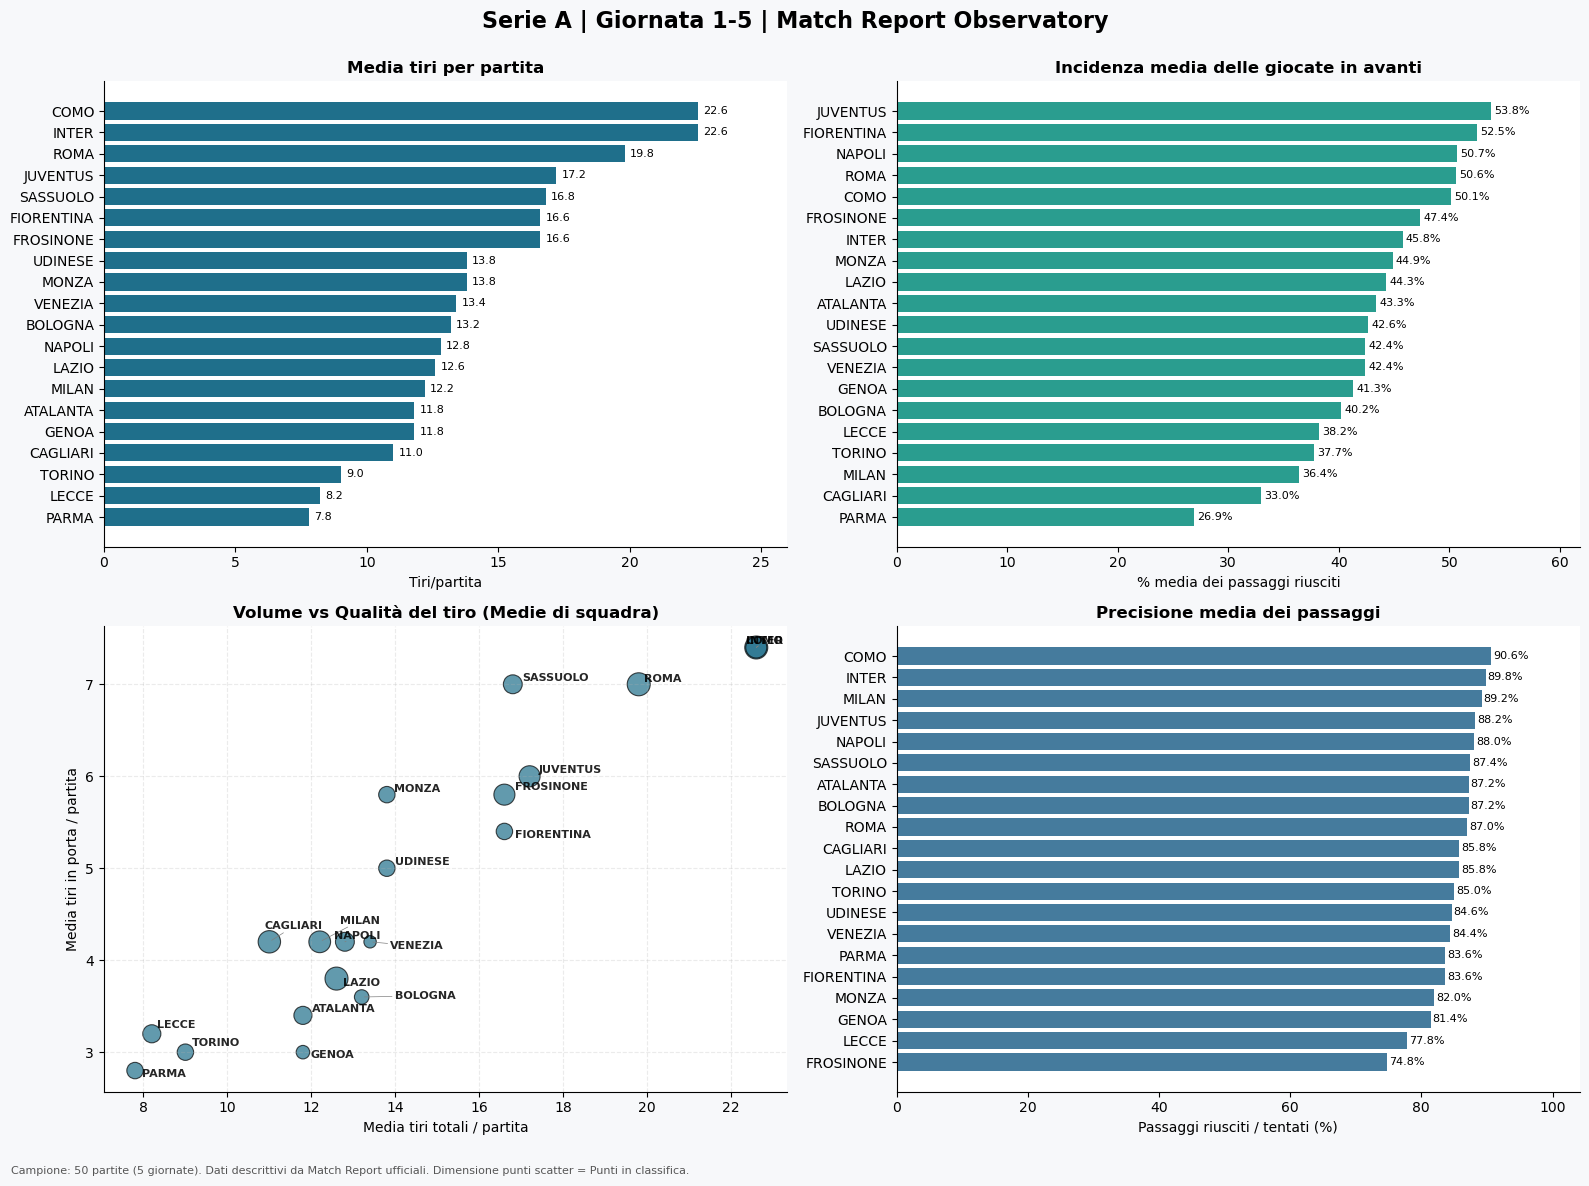

In [9]:
# Cella 8: Dashboard season-to-date con etichette dinamiche e layout pulito

from adjustText import adjust_text

colors = {"W": "#1f6f8b", "D": "#8c8c8c", "L": "#d95f59"}

giornate = match_stats_df["giornata"]
giornate_label = f"{giornate.min()}-{giornate.max()}" if giornate.nunique() > 1 else str(giornate.iloc[0])

# Usiamo subplots con layout rettificato
figure, axes = plt.subplots(2, 2, figsize=(16, 12))
figure.patch.set_facecolor("#f7f8fa")

# Subplot 1: Media tiri per partita
ranking_plot = team_summary_df.sort_values("shots_avg", ascending=True)
axes[0, 0].barh(ranking_plot["team"], ranking_plot["shots_avg"], color="#1f6f8b")
axes[0, 0].set_title("Media tiri per partita", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Tiri/partita")
axes[0, 0].set_xlim(0, ranking_plot["shots_avg"].max() * 1.15)
for i, v in enumerate(ranking_plot["shots_avg"]):
    axes[0, 0].text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=8)

# Subplot 2: Incidenza giocate in avanti
style_plot = team_summary_df.sort_values("forward_incidence_avg", ascending=True)
axes[0, 1].barh(style_plot["team"], style_plot["forward_incidence_avg"], color="#2a9d8f")
axes[0, 1].set_title("Incidenza media delle giocate in avanti", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("% media dei passaggi riusciti")
axes[0, 1].set_xlim(0, style_plot["forward_incidence_avg"].max() * 1.15)
for i, v in enumerate(style_plot["forward_incidence_avg"]):
    axes[0, 1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

# Subplot 3: Volume vs qualità del tiro (per SQUADRA con etichette anti-collisione)
axes[1, 0].scatter(
    team_summary_df["shots_avg"],
    team_summary_df["shots_on_target_avg"],
    s=team_summary_df["points"] * 15 + 80,
    color="#1f6f8b",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.8,
)
axes[1, 0].set_title("Volume vs Qualità del tiro (Medie di squadra)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Media tiri totali / partita")
axes[1, 0].set_ylabel("Media tiri in porta / partita")
axes[1, 0].grid(alpha=0.25, linestyle="--")

# Aggiunta etichette gestite da adjustText per evitare sovrapposizioni
texts = [
    axes[1, 0].annotate(
        row["team"],
        (row["shots_avg"], row["shots_on_target_avg"]),
        fontsize=8,
        fontweight="bold",
        alpha=0.85,
    )
    for _, row in team_summary_df.iterrows()
]
adjust_text(texts, ax=axes[1, 0], arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Subplot 4: Precisione dei passaggi
accuracy_plot = team_summary_df.sort_values("pass_accuracy_avg", ascending=True)
axes[1, 1].barh(accuracy_plot["team"], accuracy_plot["pass_accuracy_avg"], color="#457b9d")
axes[1, 1].set_title("Precisione media dei passaggi", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Passaggi riusciti / tentati (%)")
axes[1, 1].set_xlim(0, accuracy_plot["pass_accuracy_avg"].max() * 1.15)
for i, v in enumerate(accuracy_plot["pass_accuracy_avg"]):
    axes[1, 1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

# Applica stile pulito
for ax in axes.flat:
    ax.set_facecolor("#ffffff")
    ax.spines[["top", "right"]].set_visible(False)

# Spaziatura automatica per evitare sovrapposizioni
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Titoli e footer posizionati in punti sicuri
figure.suptitle(f"Serie A | Giornata {giornate_label} | Match Report Observatory", fontsize=16, fontweight="bold", y=0.98)
figure.text(
    0.01, 0.01,
    f"Campione: {len(match_stats_df)} partite ({giornate.nunique()} giornate). Dati descrittivi da Match Report ufficiali. Dimensione punti scatter = Punti in classifica.",
    fontsize=8, color="#555555"
)

plt.show()

In [ ]:
# Cella 9: Parsing della tabella STATISTICHE GIOCATORE (statistiche per singolo giocatore)

# A differenza di STATISTICHE SQUADRE (2 colonne fisse, casa/ospite), qui ogni
# riga giocatore ha un NUMERO VARIABILE di valori: una metrica a 0/vuota per
# quel giocatore non viene stampata affatto, non stampata come "0". Quindi non
# si può mappare per posizione sequenziale ("il 5° valore = 5° colonna") —
# serve calibrare i centri X delle colonne dall'header e assegnare ogni valore
# alla colonna più vicina, riga per riga. Verificato con coordinate reali su
# 7 PDF diversi.
#
# Nota sul legenda: la sidebar "Legenda" (a destra della pagina) sta in un
# range Y che si sovrappone alle righe giocatore — il raggruppamento per
# tolleranza-Y da solo la fonderebbe con la tabella. Va filtrata via X PRIMA
# di raggruppare in righe. Verificato su 5 PDF diversi: il Legenda parte
# sempre a x0≈391.76, mai prima — usiamo 390 come soglia sicura.
#
# AMM/DAM/ESP: nell'header questi tre si fondono in un unico token
# ("AMMDAMESP"), ma il token mantiene lo span (x0, x1) dell'intera zona
# fusa — largo 43pt sia per riga portiere che di movimento, solo posizionato
# più a sinistra o a destra secondo quante colonne reali lo precedono.
# Dividendo quello span in 3 terzi uguali si classifica il cartellino:
# verificato su 3 casi reali (AMM su ~160 casi, DAM e ESP su 1 caso
# ciascuno — J. VÁSQUEZ doppio giallo, GAETANO rosso diretto), il centro
# osservato cade entro 1.3pt dal centro predetto in tutti e 3 i casi, e la
# stessa formula spiega anche la posizione del portiere (zona spostata a
# sinistra, larghezza identica). DAM/ESP restano da confermare su più
# partite man mano che se ne accumulano — l'evidenza è solida ma il
# campione resta piccolo.

LEGEND_X_THRESHOLD = 390.0
MAX_COLUMN_MATCH_DISTANCE = 8.0  # metà circa del passo tra colonne (~15pt): oltre, la riga va revisionata

GK_COLUMNS = ["MIN", "GS", "AUT", "PA", "AS", "RE", "LU"]
OUTFIELD_COLUMNS = ["MIN", "G", "AUT", "T", "TP", "PT", "OG", "FS", "PG", "AS", "PC", "P", "P(%)", "PA", "R"]

MIN_VALUE_PATTERN = re.compile(r"^\d*'$")  # un '' vuoto (dato mancante nel PDF sorgente) va comunque
# riconosciuto come "qui iniziano i valori", altrimenti scivola dentro il nome del giocatore


def _is_gk_header(texts: list[str]) -> bool:
    """GS, RE, LU compaiono SOLO nell'header portiere."""
    return "GS" in texts and "RE" in texts and "LU" in texts


def _is_outfield_header(texts: list[str]) -> bool:
    """TP, PT, P(%) insieme compaiono SOLO nell'header di movimento."""
    return "TP" in texts and "PT" in texts and "P(%)" in texts


def _extract_team_name(line: list[dict]) -> str:
    """Nella riga header portiere il nome squadra sono i token prima di 'MIN'
    (uniti: gestisce anche nomi di più parole, es. 'HELLAS VERONA')."""
    tokens = []
    for word in line:
        if word["text"] == "MIN":
            break
        tokens.append(word["text"])
    return " ".join(tokens)


def _column_centers(line: list[dict], expected_cols: list[str]) -> dict[str, float]:
    """Centro X di ogni colonna attesa, letto dall'header di QUESTA pagina
    (mai hardcodato): se il template cambia leggermente da un report
    all'altro, la calibrazione si adatta da sola."""
    return {
        word["text"]: (word["x0"] + word["x1"]) / 2.0
        for word in line
        if word["text"] in expected_cols
    }


def _card_zone_bounds(line: list[dict]) -> tuple[float, float] | None:
    """Trova il token header fuso 'AMMDAMESP' e ritorna il suo span (x0, x1)."""
    for word in line:
        if word["text"] == "AMMDAMESP":
            return word["x0"], word["x1"]
    return None


def _classify_card(word: dict, zone_bounds: tuple[float, float] | None) -> str | None:
    """Divide la zona AMM/DAM/ESP fusa in tre terzi uguali e classifica il
    valore in base a dove cade il suo centro. None se il valore è fuori
    da quella zona (davvero non classificabile)."""
    if zone_bounds is None:
        return None
    x0, x1 = zone_bounds
    third = (x1 - x0) / 3
    center = (word["x0"] + word["x1"]) / 2.0
    if not (x0 - 2 <= center <= x1 + 2):  # piccolo margine di tolleranza
        return None
    if center < x0 + third:
        return "AMM"
    elif center < x0 + 2 * third:
        return "DAM"
    else:
        return "ESP"


def _split_name_and_values(line: list[dict]) -> tuple[str, str, list[dict]]:
    """Numero di maglia (1° token) + nome (token fino al primo valore) + token
    di valore (minutaggio 'XX'' o numerico puro). Gestisce nomi multi-parola
    (es. 'J. RODRÍGUEZ', 'UNAI GÓMEZ') perché non si ferma al primo spazio ma
    al primo token che SEMBRA un valore."""
    jersey = line[0]["text"]
    value_start = None
    for i, word in enumerate(line[1:], start=1):
        if MIN_VALUE_PATTERN.match(word["text"]) or NUMERIC_TOKEN.match(word["text"]):
            value_start = i
            break
    if value_start is None:
        return jersey, " ".join(w["text"] for w in line[1:]), []
    name = " ".join(w["text"] for w in line[1:value_start])
    return jersey, name, line[value_start:]


def _nearest_column(word: dict, header_centers: dict[str, float]) -> tuple[str, float]:
    center = (word["x0"] + word["x1"]) / 2.0
    col = min(header_centers, key=lambda c: abs(header_centers[c] - center))
    return col, abs(header_centers[col] - center)


def _parse_player_row(
    line: list[dict], header_centers: dict[str, float], role: str, team: str,
    card_zone: tuple[float, float] | None,
) -> dict[str, object]:
    """Ogni valore va alla colonna più vicina SOLO se entro tolleranza. Un
    valore fuori tolleranza viene prima provato come cartellino (AMM/DAM/ESP,
    vedi _classify_card) — solo se non classificabile nemmeno lì finisce in
    'unassigned_values'. Non sovrascrive MAI una colonna già assegnata
    correttamente (bug reale trovato e corretto in fase di validazione)."""
    jersey, name, value_words = _split_name_and_values(line)
    row: dict[str, object] = {"team": team, "role": role, "jersey": int(jersey), "player": name}
    unassigned_values: list[dict] = []

    for word in value_words:
        col, distance = _nearest_column(word, header_centers)
        if distance <= MAX_COLUMN_MATCH_DISTANCE:
            if col == "MIN":
                stripped = word["text"].rstrip("'")
                row["MIN"] = int(stripped) if stripped else None
            else:
                row[col] = parse_number(word["text"])
            continue

        card = _classify_card(word, card_zone)
        if card is not None:
            row[card] = 1
            continue

        unassigned_values.append({"x0": word["x0"], "text": word["text"], "nearest_col": col})

    row["unassigned_values"] = unassigned_values  # lista vuota = allineamento pulito
    return row


def _looks_like_player_row(line: list[dict]) -> bool:
    return line[0]["text"].isdigit()


def parse_player_stats(report_path: Path) -> list[dict]:
    """Estrae la tabella STATISTICHE GIOCATORE (entrambe le squadre, un
    dizionario per giocatore) da un singolo Match Report PDF."""
    pages = extract_page_texts(report_path)
    match_meta = extract_match_metadata(pages)
    page_number, _ = find_page(pages, "STATISTICHE GIOCATORE")

    words = extract_stats_page_words(report_path, page_number)
    table_words = [w for w in words if w["x0"] < LEGEND_X_THRESHOLD]
    lines = group_words_into_lines(table_words)

    records: list[dict] = []
    current_team: str | None = None
    current_header: dict[str, float] | None = None
    current_role: str | None = None
    current_card_zone: tuple[float, float] | None = None

    for line in lines:
        texts = [w["text"] for w in line]

        if "RANKING" in texts:
            break

        if _is_gk_header(texts):
            current_team = _extract_team_name(line)
            current_header = _column_centers(line, GK_COLUMNS)
            current_card_zone = _card_zone_bounds(line)
            current_role = "GK"
            continue

        if _is_outfield_header(texts):
            current_header = _column_centers(line, OUTFIELD_COLUMNS)
            current_card_zone = _card_zone_bounds(line)
            current_role = "OUT"
            continue

        if current_header is None or not _looks_like_player_row(line):
            continue

        row = _parse_player_row(line, current_header, current_role, current_team, current_card_zone)
        row["match_id"] = match_meta["match_id"]
        row["giornata"] = match_meta["giornata"]
        records.append(row)

    return records


In [21]:
# Cella 10: Parsing di STATISTICHE GIOCATORE per tutte le giornate disponibili in data/

player_records: list[dict] = []
player_parse_errors: list[dict] = []

for round_dir in ROUND_DIRS:
    for pdf_path in sorted(round_dir.glob("*.pdf")):
        try:
            player_records.extend(parse_player_stats(pdf_path))
        except Exception as exc:
            player_parse_errors.append({
                "folder": round_dir.name,
                "file": pdf_path.name,
                "error": str(exc),
            })

player_stats_df = pd.DataFrame(player_records)

print(f"Righe giocatore estratte: {len(player_stats_df)}")
print(f"Partite coperte: {player_stats_df['match_id'].nunique()} (attese: {len(match_stats_df)})")
print(
    "Giocatori per squadra per partita — min/max: "
    f"{player_stats_df.groupby(['match_id', 'team']).size().min()}/"
    f"{player_stats_df.groupby(['match_id', 'team']).size().max()}"
)

if player_parse_errors:
    print(f"\n⚠️ {len(player_parse_errors)} PDF con errori di parsing giocatori:")
    display(pd.DataFrame(player_parse_errors))

display(player_stats_df.head(10))


Righe giocatore estratte: 1590
Partite coperte: 50 (attese: 50)
Giocatori per squadra per partita — min/max: 15/16


,team,role,jersey,player,MIN,GS,PA,RE,LU,unassigned_values,...,R,PC,FS,T,TP,G,AS,PT,OG,AUT
0,GENOA,GK,1,BIJLOW,97.0,2.0,2.0,1.0,25.0,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GENOA,OUT,27,MARCANDALLI,97.0,NaN,17.0,NaN,NaN,[],...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GENOA,OUT,5,ØSTIGÅRD,67.0,NaN,9.0,NaN,NaN,"[{'x0': 340.04295833154276, 'text': '1', 'near...",...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GENOA,OUT,22,J. VÁSQUEZ,89.0,NaN,9.0,NaN,NaN,[],...,7.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GENOA,OUT,15,NORTON-CUFFY,97.0,NaN,16.0,NaN,NaN,[],...,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,GENOA,OUT,32,FRENDRUP,97.0,NaN,29.0,NaN,NaN,[],...,7.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
6,GENOA,OUT,4,AMORIM,76.0,NaN,26.0,NaN,NaN,[],...,3.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
7,GENOA,OUT,77,ELLERTSSON,97.0,NaN,15.0,NaN,NaN,[],...,4.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
8,GENOA,OUT,8,BALDANZI,67.0,NaN,21.0,NaN,NaN,[],...,2.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
9,GENOA,OUT,9,VITINHA,97.0,NaN,7.0,NaN,NaN,[],...,9.0,NaN,1.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN


In [22]:
# Cella 11: Verifica diagnostica — righe con valori non allineati (unassigned_values)

# Stesso principio della Cella 6 per le squadre: non ci si fida del "gira senza
# errori", si controllano esplicitamente le righe che il parser ha scartato
# invece di indovinare. Nei 3 PDF di validazione, gli unici flag erano
# esattamente i giocatori ammoniti in quella partita (il cartellino cade nella
# zona AMMDAMESP esclusa) — nessun falso positivo/negativo.

flagged = player_stats_df[player_stats_df["unassigned_values"].apply(len) > 0]
print(f"Righe con unassigned_values non vuoto: {len(flagged)} su {len(player_stats_df)}")

if not flagged.empty:
    display(flagged[["match_id", "team", "jersey", "player", "unassigned_values"]])

print(f"\nGiocatori totali estratti: {player_stats_df['player'].nunique()}")
print(f"Portieri (role=GK): {(player_stats_df['role'] == 'GK').sum()}")
print(f"Giocatori di movimento (role=OUT): {(player_stats_df['role'] == 'OUT').sum()}")


Righe con unassigned_values non vuoto: 160 su 1590


,match_id,team,jersey,player,unassigned_values
2,G01_GENOA_NAPOLI,GENOA,5,ØSTIGÅRD,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
24,G01_GENOA_NAPOLI,NAPOLI,21,POLITANO,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
38,G01_INTER_MONZA,INTER,20,ÇALHANOĞLU,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
42,G01_INTER_MONZA,INTER,10,L. MARTÍNEZ,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
49,G01_INTER_MONZA,MONZA,60,KOUADIO,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
...,...,...,...,...,...
1487,G03_UDINESE_LAZIO,LAZIO,11,ISAKSEN,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
1511,G03_ROMA_ATALANTA,ATALANTA,16,BELLANOVA,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
1527,G03_BOLOGNA_SASSUOLO,BOLOGNA,2,HOLM,"[{'x0': 340.04295833154276, 'text': '1', 'near..."
1538,G03_BOLOGNA_SASSUOLO,BOLOGNA,9,DOVBYK,"[{'x0': 340.04295833154276, 'text': '1', 'near..."



Giocatori totali estratti: 461
Portieri (role=GK): 101
Giocatori di movimento (role=OUT): 1489


In [23]:
# Cella 12: Diagnostica batch su tutte le giornate (sanity check su volumi anomali)

# 1. Team-partita con più di 1 portiere — isola il caso dei 101 vs 100 attesi
gk_counts = player_stats_df[player_stats_df["role"] == "GK"].groupby(["match_id", "team"]).size()
extra_gk = gk_counts[gk_counts > 1]
print(f"Team-partita con più di 1 portiere: {len(extra_gk)}")
if not extra_gk.empty:
    display(extra_gk.reset_index(name="n_portieri"))

# 2. Roster per team-partita fuori dal range plausibile [14, 18]
roster_counts = player_stats_df.groupby(["match_id", "team"]).size()
print(f"\nGiocatori per team-partita — min={roster_counts.min()}, max={roster_counts.max()}, mediana={roster_counts.median()}")
outliers = roster_counts[(roster_counts < 14) | (roster_counts > 18)]
if not outliers.empty:
    print(f"⚠️ {len(outliers)} team-partita fuori range:")
    display(outliers.reset_index(name="n_giocatori"))

# 3. Righe con PIÙ di 1 valore scartato — se >1, potrebbe non essere un semplice cartellino
n_unassigned = player_stats_df["unassigned_values"].apply(len)
print(f"\nDistribuzione unassigned_values per riga:\n{n_unassigned.value_counts().sort_index()}")

multi_flagged = player_stats_df[n_unassigned > 1]
if not multi_flagged.empty:
    print(f"\n⚠️ {len(multi_flagged)} righe con più di 1 token scartato:")
    display(multi_flagged[["match_id", "team", "player", "unassigned_values"]])

Team-partita con più di 1 portiere: 1


,match_id,team,n_portieri
0,G01_FROSINONE_JUVENTUS,JUVENTUS,2



Giocatori per team-partita — min=15, max=16, mediana=16.0

Distribuzione unassigned_values per riga:
unassigned_values
0    1430
1     160
Name: count, dtype: int64


In [24]:
# Cella 13: Distribuzione delle coordinate X dei valori scartati

unassigned_df = player_stats_df[player_stats_df["unassigned_values"].apply(len) > 0].copy()
unassigned_df["flag_x0"] = unassigned_df["unassigned_values"].apply(lambda v: round(v[0]["x0"], 2))
unassigned_df["flag_text"] = unassigned_df["unassigned_values"].apply(lambda v: v[0]["text"])

print("Distribuzione x0 dei valori scartati:")
print(unassigned_df["flag_x0"].value_counts())
print("\nDistribuzione testo dei valori scartati:")
print(unassigned_df["flag_text"].value_counts())

Distribuzione x0 dei valori scartati:
flag_x0
340.04    157
220.42      2
355.00      1
Name: count, dtype: int64

Distribuzione testo dei valori scartati:
flag_text
1    160
Name: count, dtype: int64


In [25]:
# Cella 14: Isola i 3 valori scartati con x0 diverso da 340.04 (il caso AMM "normale")

anomalie = unassigned_df[unassigned_df["flag_x0"] != 340.04]
display(anomalie[["match_id", "team", "jersey", "player", "flag_x0", "flag_text"]])

,match_id,team,jersey,player,flag_x0,flag_text
386,G04_GENOA_FROSINONE,GENOA,22,J. VÁSQUEZ,355.00,1
699,G05_FIORENTINA_NAPOLI,FIORENTINA,43,DE GEA,220.42,1
1383,G03_CAGLIARI_LECCE,LECCE,30,FALCONE ',220.42,1


In [26]:
# Cella 15: Verifica se la soglia 360 taglia dati veri, su un campione di 5 partite


check_paths = list(Path("data").rglob("*.pdf"))[:5]
for p in check_paths:
    pages = extract_page_texts(p)
    page_number, _ = find_page(pages, "STATISTICHE GIOCATORE")
    words = extract_stats_page_words(p, page_number)
    legend_words = [w for w in words if w["text"] == "Legenda"]
    legend_x0 = legend_words[0]["x0"] if legend_words else None
    beyond_threshold = [w for w in words if 334 <= w["x0"] < (legend_x0 or 999)]
    print(f"{p.name[:30]:30s} legenda a x0={legend_x0} | words tra 334 e legenda: {len(beyond_threshold)}")

87efe7bc3660456ca4b7c9426ad0fa legenda a x0=391.7577961767578 | words tra 334 e legenda: 18
e4fe3e637d6e496fb6a905a0b183ed legenda a x0=391.7577961767578 | words tra 334 e legenda: 16
160ddffa5500412baf2c48c2ea2556 legenda a x0=391.7577961767578 | words tra 334 e legenda: 13
e5e1363d12bf4adfb494f64c3654c1 legenda a x0=391.7577961767578 | words tra 334 e legenda: 19
8555be7ed28343a196cce24873f245 legenda a x0=391.7577961767578 | words tra 334 e legenda: 15


In [ ]:
# Cella 16: Aggregazione season-level per giocatore

# Nota sul modello dati: la colonna "PA" ha significati DIVERSI a seconda del
# ruolo — per un portiere è "Parate", per un giocatore di movimento è "Palloni
# giocati in avanti riusciti" (stessa sigla nel PDF, due metriche diverse, già
# visto in Cella 9). Per questo aggreghiamo SEPARATAMENTE i portieri
# (role == "GK") dai giocatori di movimento (role == "OUT").
#
# Nota sui minuti mancanti: in alcuni PDF il campo MIN non contiene le cifre
# (visto sui titolari del Lecce in Cagliari-Lecce, G3: il dato non esiste nel
# file sorgente). Per i tassi per-90 quelle righe vanno escluse SIA dai minuti
# SIA dalle statistiche, altrimenti il numeratore include partite di cui manca
# il denominatore e il tasso risulta gonfiato. I totali "grezzi" (gol, tiri...)
# restano invece calcolati su tutte le partite.
#
# Nota sulla precisione passaggi: media PESATA (passaggi completati totali /
# tentati totali), non media semplice delle percentuali per partita. I "tentati"
# sono ricostruiti da P e P(%) (arrotondato a intero nel PDF): approssimazione.
#
# STATISTICHE GIOCATORE non include Dribbling né "Passaggi in ultimo terzo" per
# singolo giocatore (esistono solo a livello squadra e nei top-5 RANKING).

# Soglie: minuti = 40% dei minuti disponibili finora (scala da sola durante la
# stagione, minimo 180'); passaggi = volume minimo per le classifiche su percentuali
matchdays_played = player_stats_df["giornata"].nunique()
MIN_MINUTES_FOR_RATES = max(180, round(0.4 * 90 * matchdays_played))
MIN_PASSES_FOR_PCT = 50


def _ensure_columns(df, columns):
    """Garantisce che le colonne esistano anche se assenti in questo sottoinsieme
    (es. AUT-autogol, raro) — altrimenti .agg() con nome fisso va in KeyError."""
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            df[col] = np.nan
    return df


outfield_rows = _ensure_columns(
    player_stats_df[player_stats_df["role"] == "OUT"],
    ["G", "AUT", "T", "TP", "PT", "OG", "FS", "PG", "AS", "PC", "P", "P(%)", "PA", "R", "AMM", "DAM", "ESP"],
)
gk_rows = _ensure_columns(
    player_stats_df[player_stats_df["role"] == "GK"],
    ["GS", "AUT", "PA", "AS", "RE", "LU", "AMM", "DAM", "ESP"],
)
for _df in (outfield_rows, gk_rows):
    _df["MIN"] = pd.to_numeric(_df["MIN"], errors="coerce")

# Statistiche "con minuti validi", usate solo per i tassi per-90
PER90_SOURCES = {"goals": "G", "assists": "AS", "shots": "T", "key_passes": "PC", "recoveries": "R"}
for name, source in PER90_SOURCES.items():
    outfield_rows[f"{name}_timed"] = outfield_rows[source].where(outfield_rows["MIN"].notna())
gk_rows["goals_conceded_timed"] = gk_rows["GS"].where(gk_rows["MIN"].notna())

outfield_rows["passes_attempted"] = np.where(
    outfield_rows["P(%)"] > 0, outfield_rows["P"] / (outfield_rows["P(%)"] / 100), np.nan
)

player_summary_df = (
    outfield_rows.groupby(["player", "team"], as_index=False)
    .agg(
        matches=("match_id", "size"),
        matches_no_minutes=("MIN", lambda s: int(s.isna().sum())),
        minutes=("MIN", "sum"),
        goals=("G", "sum"),
        own_goals=("AUT", "sum"),
        shots=("T", "sum"),
        shots_on_target=("TP", "sum"),
        woodwork=("PT", "sum"),
        big_chances=("OG", "sum"),
        fouls_suffered=("FS", "sum"),
        touches=("PG", "sum"),
        assists=("AS", "sum"),
        key_passes=("PC", "sum"),
        passes_completed=("P", "sum"),
        passes_attempted=("passes_attempted", "sum"),
        forward_passes=("PA", "sum"),
        recoveries=("R", "sum"),
        amm=("AMM", "sum"),
        dam=("DAM", "sum"),
        esp=("ESP", "sum"),
        goals_timed=("goals_timed", "sum"),
        assists_timed=("assists_timed", "sum"),
        shots_timed=("shots_timed", "sum"),
        key_passes_timed=("key_passes_timed", "sum"),
        recoveries_timed=("recoveries_timed", "sum"),
    )
)

player_summary_df["pass_accuracy_pct"] = (
    player_summary_df["passes_completed"] / player_summary_df["passes_attempted"] * 100
)
player_summary_df["forward_play_incidence_pct"] = (
    player_summary_df["forward_passes"] / player_summary_df["passes_completed"] * 100
)

eligible = player_summary_df["minutes"] >= MIN_MINUTES_FOR_RATES
for name in PER90_SOURCES:
    player_summary_df[f"{name}_per90"] = np.where(
        eligible, player_summary_df[f"{name}_timed"] / player_summary_df["minutes"] * 90, np.nan
    )
player_summary_df = (
    player_summary_df.drop(columns=[f"{n}_timed" for n in PER90_SOURCES])
    .sort_values("minutes", ascending=False)
    .reset_index(drop=True)
)

# --- Portieri, tabella separata ---
keeper_summary_df = (
    gk_rows.groupby(["player", "team"], as_index=False)
    .agg(
        matches=("match_id", "size"),
        matches_no_minutes=("MIN", lambda s: int(s.isna().sum())),
        minutes=("MIN", "sum"),
        goals_conceded=("GS", "sum"),
        goals_conceded_timed=("goals_conceded_timed", "sum"),
        own_goals=("AUT", "sum"),
        saves=("PA", "sum"),       # per il portiere, PA = Parate
        respinte=("RE", "sum"),
        long_balls=("LU", "sum"),
        assists=("AS", "sum"),
        amm=("AMM", "sum"),
        dam=("DAM", "sum"),
        esp=("ESP", "sum"),
    )
)
keeper_summary_df["save_pct"] = (
    keeper_summary_df["saves"] / (keeper_summary_df["saves"] + keeper_summary_df["goals_conceded"]) * 100
)
keeper_summary_df["goals_conceded_per90"] = np.where(
    keeper_summary_df["minutes"] >= MIN_MINUTES_FOR_RATES,
    keeper_summary_df["goals_conceded_timed"] / keeper_summary_df["minutes"] * 90,
    np.nan,
)
keeper_summary_df = (
    keeper_summary_df.drop(columns=["goals_conceded_timed"])
    .sort_values("minutes", ascending=False)
    .reset_index(drop=True)
)

print(f"Soglia minuti per i tassi per-90: {MIN_MINUTES_FOR_RATES}' ({matchdays_played} giornate) | soglia passaggi per le %: {MIN_PASSES_FOR_PCT}")
print(f"Giocatori di movimento distinti: {player_summary_df['player'].nunique()} | idonei per-90: {int(eligible.sum())}")
print(f"Portieri distinti: {keeper_summary_df['player'].nunique()}")

no_minutes = player_stats_df.assign(_m=pd.to_numeric(player_stats_df["MIN"], errors="coerce"))
no_minutes = no_minutes[no_minutes["_m"].isna()]
print(f"\nRighe giocatore con MIN mancante nel PDF sorgente: {len(no_minutes)}")
if not no_minutes.empty:
    display(no_minutes.groupby(["match_id", "team"]).size().rename("righe_senza_minuti").reset_index())

display(player_summary_df.head(10))
display(keeper_summary_df.head(10))


In [ ]:
# Cella 17: Ranking tematici giocatori — grafici (season-to-date)

# Le classifiche testuali usate finora bastavano per un controllo puntuale,
# ma per decidere cosa merita un posto in dashboard serve vedere la
# DISTRIBUZIONE, non solo il nome in cima: un gap netto tra il 1° e il 10°
# posto è un segnale forte, una classifica "piatta" molto meno. Da qui in
# poi lavoriamo quindi soprattutto per grafici; le tabelle restano solo
# dove il numero esatto conta più della forma (disciplina, portieri).

def _topn_barh(ax, df, col, title, xlabel, color, n=10, pct=False):
    """Bar chart orizzontale dei top-n per col — un'unica funzione al posto
    di ripetere lo stesso boilerplate matplotlib per ogni metrica, qui e in
    Cella 18. Gestisce anche il caso (frequente a inizio stagione, con pochi
    giocatori idonei) in cui df sia vuoto o più corto di n."""
    plot_df = df.nlargest(min(n, len(df)), col).sort_values(col, ascending=True)
    if plot_df.empty:
        ax.set_title(f"{title}\n(nessun giocatore idoneo nel campione)", fontsize=10)
        ax.axis("off")
        return
    labels = plot_df["player"] + " (" + plot_df["team"].str[:3] + ")"
    suffix = "%" if pct else ""
    ax.barh(labels, plot_df[col], color=color)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_xlim(0, plot_df[col].max() * 1.2)
    for i, v in enumerate(plot_df[col]):
        ax.text(v + plot_df[col].max() * 0.02, i, f"{v:.1f}{suffix}", va="center", fontsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)


eligible_players = player_summary_df[player_summary_df["minutes"] >= MIN_MINUTES_FOR_RATES]
pct_pool = eligible_players[eligible_players["passes_completed"] >= MIN_PASSES_FOR_PCT]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f"Classifiche giocatori per 90' — min. {MIN_MINUTES_FOR_RATES}' giocati ({len(eligible_players)} idonei)",
    fontsize=14, fontweight="bold",
)
_topn_barh(axes[0, 0], eligible_players, "goals_per90", "Gol per 90'", "Gol/90'", "#d95f59")
_topn_barh(axes[0, 1], eligible_players, "assists_per90", "Assist per 90'", "Assist/90'", "#e08e45")
_topn_barh(axes[0, 2], eligible_players, "shots_per90", "Tiri per 90'", "Tiri/90'", "#1f6f8b")
_topn_barh(axes[1, 0], eligible_players, "key_passes_per90", "Passaggi chiave per 90'", "Passaggi chiave/90'", "#2a9d8f")
_topn_barh(axes[1, 1], eligible_players, "recoveries_per90", "Recuperi per 90'", "Recuperi/90'", "#457b9d")
_topn_barh(
    axes[1, 2], pct_pool, "pass_accuracy_pct",
    f"Precisione passaggi (min. {MIN_PASSES_FOR_PCT} passaggi)", "%", "#6a4c93", pct=True,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Nota sull'incidenza delle giocate in avanti: dipende troppo dal ruolo (gli
# attaccanti giocano quasi solo in avanti) per essere una classifica onesta
# tra giocatori diversi — la teniamo fuori dai grafici, resta disponibile
# come colonna in player_summary_df per chi la vuole guardare per ruolo.

# --- Disciplina e portieri: conteggi, non tassi — restano più leggibili come classifica a barre semplice ---
# (Cella 9: DAM include entrambi i gialli dell'espulsione per doppia ammonizione,
# quindi gialli_equivalenti = amm + 2*dam evita di contare due volte lo stesso episodio)
discipline = player_summary_df[["player", "team", "amm", "dam", "esp"]].copy()
discipline["gialli_equivalenti"] = discipline["amm"].fillna(0) + 2 * discipline["dam"].fillna(0)
discipline = discipline.sort_values(["gialli_equivalenti", "esp"], ascending=False)

eligible_gk = keeper_summary_df[keeper_summary_df["minutes"] >= MIN_MINUTES_FOR_RATES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_topn_barh(axes[0], discipline, "gialli_equivalenti", "Disciplina — gialli equivalenti", "Giallo + 2×doppio giallo", "#e9c46a")
_topn_barh(axes[1], eligible_gk, "save_pct", f"Portieri — % parate (min. {MIN_MINUTES_FOR_RATES}')", "%", "#264653", pct=True)
plt.tight_layout()
plt.show()

card_cols = [c for c in ("DAM", "ESP") if c in player_stats_df.columns]
sent_off = player_stats_df[player_stats_df[card_cols].notna().any(axis=1)] if card_cols else player_stats_df.iloc[0:0]
print(f"Espulsioni/doppie ammonizioni in stagione: {len(sent_off)} — da confrontare con la Cronologia:")
cols = [c for c in ["match_id", "team", "player", "AMM", "DAM", "ESP"] if c in sent_off.columns]
print(sent_off[cols].to_string(index=False) if not sent_off.empty else "(nessuno nel campione)")


In [ ]:
# Cella 18: Isolare il talento individuale dal contesto squadra — grafici

# STATISTICHE GIOCATORE non contiene ruolo/posizione: un punteggio composito
# unico (gol + passaggi chiave + recuperi) confronterebbe attaccanti,
# centrocampisti e difensori sulla stessa scala, premiando sempre i profili
# box-to-box. Restiamo quindi su due strumenti separati e più onesti:
#   1) chi produce di più per 90', tra le squadre in metà bassa classifica;
#   2) quanto della produzione della SUA squadra passa da lui — già
#      normalizzato, quindi confrontabile anche tra squadre diverse.
# Richiede team_summary_df/team_match_df (Cella 4) ed eligible_players +
# _topn_barh (Cella 17).

n_teams = team_summary_df["team"].nunique()
team_rank = team_summary_df[["team", "rank"]]
weak_teams = set(team_summary_df.loc[team_summary_df["rank"] > n_teams / 2, "team"])
print(f"Squadre nella metà bassa della classifica attuale ({len(weak_teams)}/{n_teams}): {sorted(weak_teams)}")
print("(soglia sulla classifica corrente, arbitraria — da ricalibrare quando sarà più stabile)\n")

weak_pool = eligible_players[eligible_players["team"].isin(weak_teams)].merge(team_rank, on="team", how="left")

team_totals = team_match_df.groupby("team").agg(
    team_shots=("Tiri", "sum"), team_key_passes=("Passaggi chiave", "sum"), team_recoveries=("Recuperi", "sum"),
).reset_index()
share_df = weak_pool.merge(team_totals, on="team").merge(team_summary_df[["team", "goals_for"]], on="team")
share_df["goal_share_pct"] = share_df["goals"] / share_df["goals_for"].replace(0, np.nan) * 100
share_df["shot_share_pct"] = share_df["shots"] / share_df["team_shots"] * 100
share_df["key_pass_share_pct"] = share_df["key_passes"] / share_df["team_key_passes"] * 100
share_df["recovery_share_pct"] = share_df["recoveries"] / share_df["team_recoveries"] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Quota sulla produzione della squadra — solo squadre in metà bassa classifica", fontsize=13, fontweight="bold")
_topn_barh(axes[0], share_df, "shot_share_pct", "% dei tiri della squadra", "%", "#1f6f8b", pct=True)
_topn_barh(axes[1], share_df, "key_pass_share_pct", "% dei passaggi chiave della squadra", "%", "#2a9d8f", pct=True)
_topn_barh(axes[2], share_df, "recovery_share_pct", "% dei recuperi della squadra", "%", "#457b9d", pct=True)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --- Profilo produzione: passaggi chiave vs recuperi, per 90' ---
# Il quadrante in alto a destra (tanti passaggi chiave E tanti recuperi per
# 90') è il segnale più interessante per uno scouting mirato: incidenza sia
# offensiva sia difensiva, in una squadra debole — esattamente il profilo
# che un punteggio composito unico nasconderebbe.
if not weak_pool.empty:
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(
        weak_pool["key_passes_per90"], weak_pool["recoveries_per90"],
        s=weak_pool["minutes"] / weak_pool["minutes"].max() * 300 + 40,
        c=weak_pool["rank"], cmap="autumn_r", alpha=0.75, edgecolor="black", linewidth=0.6,
    )
    texts = [
        ax.annotate(
            f"{row['player']} ({row['team'][:3]})", (row["key_passes_per90"], row["recoveries_per90"]),
            fontsize=8, fontweight="bold",
        )
        for _, row in weak_pool.iterrows()
    ]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
    ax.set_xlabel("Passaggi chiave per 90'")
    ax.set_ylabel("Recuperi per 90'")
    ax.set_title("Profilo offensivo/difensivo — giocatori di squadre in metà bassa classifica", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.25, linestyle="--")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Posizione in classifica (più alto = squadra più debole)")
    plt.tight_layout()
    plt.show()
else:
    print("Nessun giocatore idoneo (per minuti) nelle squadre di metà bassa classifica in questo campione.")

display(
    share_df.sort_values("key_pass_share_pct", ascending=False)[
        ["player", "team", "rank", "minutes", "goal_share_pct", "shot_share_pct", "key_pass_share_pct", "recovery_share_pct"]
    ].head(10)
)


In [ ]:
# Cella 19: Riconciliazione giocatori vs squadra (validazione del parser)

# Vive SOLO qui: non compare mai nella dashboard — è un controllo di lavoro
# per noi (il parser mappa le colonne giuste?), non un'informazione per chi
# guarda i dati. La logica è in src/data_quality.py, condivisa e non
# duplicata qui, per non doverla riscrivere ogni volta che si aggiungono
# nuove giornate.
#
# Promemoria dalle indagini fatte con le coordinate reali (Udinese-Lazio,
# Monza-Udinese, Atalanta-Sassuolo): quando emerge uno scostamento, il
# valore individuale è SEMPRE centrato esattamente sulla colonna giusta —
# non è mai un bug di mappatura del parser, è un'incongruenza già presente
# tra le due pagine (STATISTICHE SQUADRE vs STATISTICHE GIOCATORE) dello
# stesso PDF sorgente. Uno scostamento piccolo e isolato è rumore atteso
# della fonte dati; il segnale da tenere d'occhio è che NON cresca in
# numero o dimensione aggiungendo giornate.

from src.data_quality import check_team_vs_player_consistency

issues_df = check_team_vs_player_consistency(team_match_df, player_stats_df)

print(f"Campione: {len(team_match_df)} righe squadra-partita · scostamenti trovati: {len(issues_df)}\n")

if issues_df.empty:
    print("✅ Nessuno scostamento — tutte le metriche tornano su tutte le team-partite di questo campione.")
else:
    summary = (
        issues_df.groupby("metrica")
        .agg(occorrenze=("scostamento", "size"), scostamento_max=("scostamento", lambda s: s.abs().max()))
        .reset_index()
        .sort_values("occorrenze", ascending=False)
    )
    display(summary)
    print("\nDettaglio riga per riga:")
    display(issues_df)
